In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


--- Task 1: Loading Dataset ---


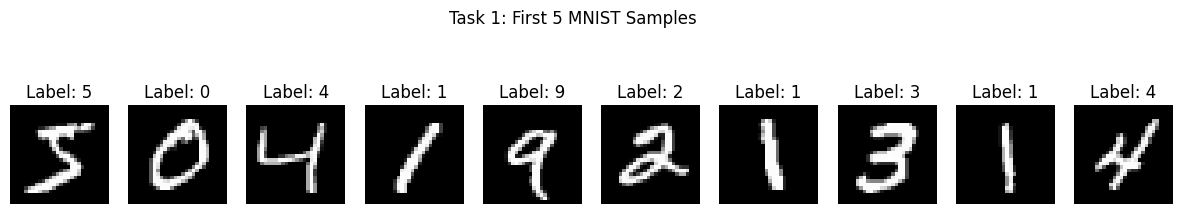

In [2]:

print("--- Task 1: Loading Dataset ---")
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Plot the first 5 samples
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.suptitle("Task 1: First 5 MNIST Samples")
plt.show()


In [3]:

print("--- Task 2: Normalizing Data ---")
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print(f"Original min/max: {X_train.min()}/{X_train.max()}")
print(f"Normalized min/max: {X_train_norm.min()}/{X_train_norm.max()}")

--- Task 2: Normalizing Data ---
Original min/max: 0/255
Normalized min/max: 0.0/1.0


In [4]:

def build_base_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),  # Input layer (flattens 28x28 to 784 vector)
        layers.Dense(128, activation='relu'),   # Layer 1: Dense hidden layer
        layers.Dense(10, activation='softmax')  # Layer 2: Output layer (10 classes)
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

base_model = build_base_model()
print("\n--- Task 3: Base Model Architecture ---")
base_model.summary()


--- Task 3: Base Model Architecture ---
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101,770
Trainable params: 101,770
Non-trainable params: 0
_________________________________________________________________



--- Task 4: Training Base Model ---
Epoch 1/10
750/750 [==============================] - 5s 5ms/step - loss: 0.3335 - accuracy: 0.9058 - val_loss: 0.1905 - val_accuracy: 0.9460
Epoch 2/10
750/750 [==============================] - 3s 4ms/step - loss: 0.1511 - accuracy: 0.9561 - val_loss: 0.1327 - val_accuracy: 0.9628
Epoch 3/10
750/750 [==============================] - 3s 4ms/step - loss: 0.1061 - accuracy: 0.9694 - val_loss: 0.1082 - val_accuracy: 0.9680
Epoch 4/10
750/750 [==============================] - 3s 4ms/step - loss: 0.0806 - accuracy: 0.9765 - val_loss: 0.1000 - val_accuracy: 0.9704
Epoch 5/10
750/750 [==============================] - 4s 5ms/step - loss: 0.0633 - accuracy: 0.9814 - val_loss: 0.0955 - val_accuracy: 0.9721
Epoch 6/10
750/750 [==============================] - 3s 4ms/step - loss: 0.0507 - accuracy: 0.9849 - val_loss: 0.0880 - val_accuracy: 0.9737
Epoch 7/10
750/750 [==============================] - 5s 7ms/step - loss: 0.0411 - accuracy: 0.9883 - val_loss:

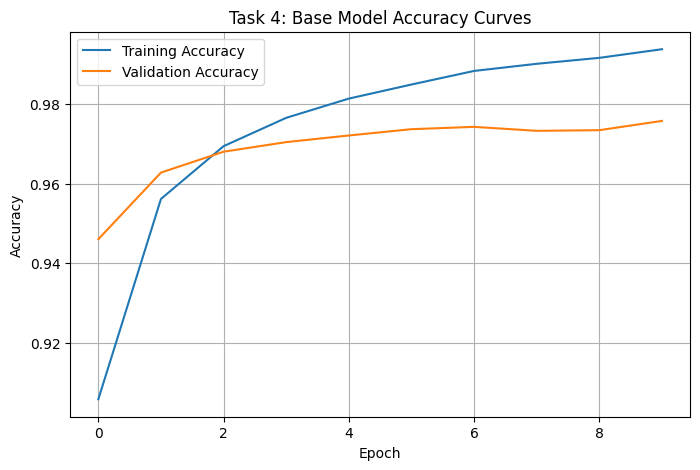

In [5]:

print("\n--- Task 4: Training Base Model ---")
history_base = base_model.fit(
    X_train_norm, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2, # 20% validation split
    verbose=1
)

# Plot training vs validation accuracy curves
plt.figure(figsize=(8, 5))
plt.plot(history_base.history['accuracy'], label='Training Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')
plt.title('Task 4: Base Model Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


--- Task 5: Evaluating Base Model ---
Test Set Accuracy: 0.9762
313/313 [==============================] - 2s 6ms/step
Total Misclassified Images in Test Set: 238


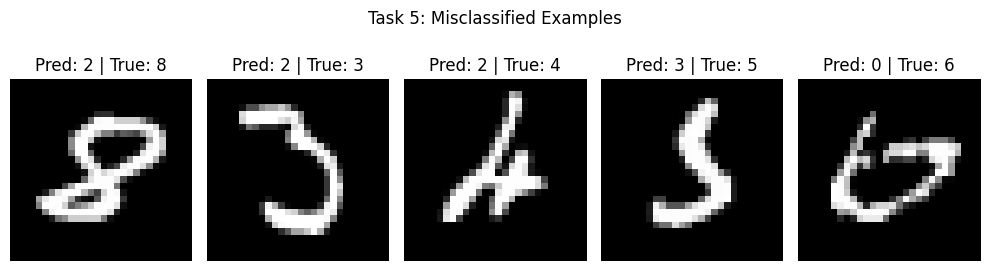

In [6]:

print("\n--- Task 5: Evaluating Base Model ---")
test_loss, test_acc = base_model.evaluate(X_test_norm, y_test, verbose=0)
print(f"Test Set Accuracy: {test_acc:.4f}")

# Find misclassified examples
predictions = base_model.predict(X_test_norm)
pred_labels = np.argmax(predictions, axis=1)
misclassified_indices = np.where(pred_labels != y_test)[0]

print(f"Total Misclassified Images in Test Set: {len(misclassified_indices)}")

# Plot 5 misclassified examples
plt.figure(figsize=(10, 3))
for i, idx in enumerate(misclassified_indices[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f"Pred: {pred_labels[idx]} | True: {y_test[idx]}")
    plt.axis('off')
plt.suptitle("Task 5: Misclassified Examples")
plt.tight_layout()
plt.show()


--- Task 6: Training Dropout Model ---
Epoch 1/10
750/750 [==============================] - 12s 13ms/step - loss: 0.4103 - accuracy: 0.8804 - val_loss: 0.1911 - val_accuracy: 0.9461
Epoch 2/10
750/750 [==============================] - 11s 14ms/step - loss: 0.2057 - accuracy: 0.9400 - val_loss: 0.1394 - val_accuracy: 0.9599
Epoch 3/10
750/750 [==============================] - 12s 16ms/step - loss: 0.1552 - accuracy: 0.9549 - val_loss: 0.1155 - val_accuracy: 0.9664
Epoch 4/10
750/750 [==============================] - 5s 6ms/step - loss: 0.1290 - accuracy: 0.9615 - val_loss: 0.1022 - val_accuracy: 0.9697
Epoch 5/10
750/750 [==============================] - 4s 5ms/step - loss: 0.1114 - accuracy: 0.9665 - val_loss: 0.0931 - val_accuracy: 0.9724
Epoch 6/10
750/750 [==============================] - 5s 7ms/step - loss: 0.0987 - accuracy: 0.9700 - val_loss: 0.0881 - val_accuracy: 0.9738
Epoch 7/10
750/750 [==============================] - 4s 5ms/step - loss: 0.0884 - accuracy: 0.9735 - 

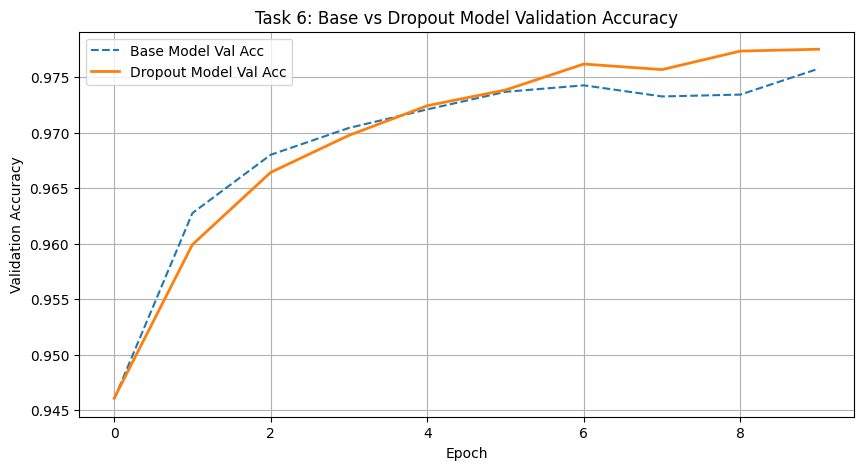


=== Final Test Comparison ===
Base Model Test Accuracy:    0.9762
Dropout Model Test Accuracy: 0.9768


In [7]:

def build_dropout_model():
    model = keras.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),                   # Dropout layer (30% rate)
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

dropout_model = build_dropout_model()
print("\n--- Task 6: Training Dropout Model ---")
history_dropout = dropout_model.fit(
    X_train_norm, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

# Evaluate Dropout Model
dropout_test_loss, dropout_test_acc = dropout_model.evaluate(X_test_norm, y_test, verbose=0)

# Compare both models visually
plt.figure(figsize=(10, 5))
plt.plot(history_base.history['val_accuracy'], label='Base Model Val Acc', linestyle='--')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout Model Val Acc', linewidth=2)
plt.title('Task 6: Base vs Dropout Model Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print("\n=== Final Test Comparison ===")
print(f"Base Model Test Accuracy:    {test_acc:.4f}")
print(f"Dropout Model Test Accuracy: {dropout_test_acc:.4f}")